# Aufgabe 0
Im Vorversuch haben wir für einen einfachen ungekoppelten Schwingkreis die Eigenfrequenz bestimmt. Dabei haben wir für den vorgegebenen Kondensator und Spule welche wir auf 1500 Henry eingesteckt haben und eine Anfangsspannung $U_a$ von 10V genutzt. Daraus haben wir eine Eigenfrequenz von $1,813 kHz$ herausbekommen.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv('Messungen/E17_Vorversuch.csv')
df.columns = df.columns.str.replace('"', '').str.strip()


# Zeitspalte erzeugen
df['Zeitstempel'] = pd.to_datetime(
    df['Jahr'].astype(str) + "-" +
    df['Monat'].astype(str).str.zfill(2) + "-" +
    df['Tag'].astype(str).str.zfill(2) + " " +
    df['Stunde'].astype(str).str.zfill(2) + ":" +
    df['Minute'].astype(str).str.zfill(2) + ":" +
    df['Sekunde'].astype(str).str.zfill(2),
    format='%Y-%m-%d %H:%M:%S'
)

# Plot für a_x
plt.figure(figsize=(10, 4))
plt.plot(df['Zeitstempel'], df['Lux (lx)'], label="Lichtstärke", color="blue")
plt.xlabel("Zeit (Monat-Tag Stunde)")
plt.ylabel("Lux (lx)")
plt.title("Lichtstärke über die Zeit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Aufgabe 1


In Aufgabe 1 haben wir die "Tiefpunkt-Schaltung" nachgebaut mit den Bauteilen welche wir auch im Vorversuch verwendet haben und folgenden Schaltkreis aus dem Skript dafür verwendet:
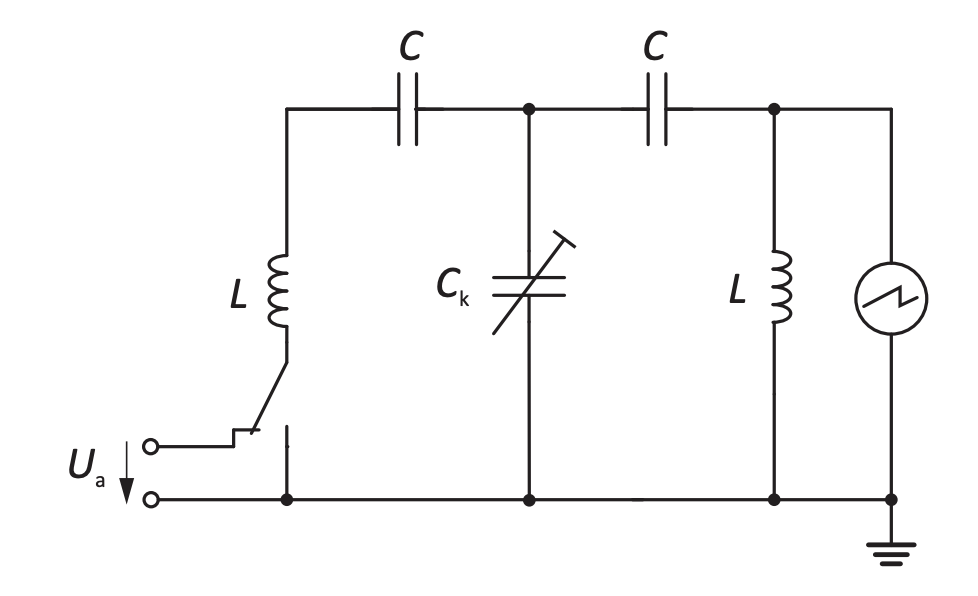

Dann haben wir durch ausprobieren geguckt, in welchem Bereich wir Schwebung beobachten können und somit die gleich- und gegensinnige Schwingung messen können. Da kamen wir auf den Bereich zwischen $10nF$ und $5000nF$, wobei wir für gute Messdaten eine logarithmische Verteilung verwendet haben. Dabei ist uns aufgefallen, dass die Frequenz der gleichsinnigen Schwingung fast immer gleich geblieben ist und nahe $f_0$ war und die gegensinnige Schwingung immer ausgeprägerter wurde und sich immer mehr der gleichsinnigen angenähert hat. Im folgenden sieht man unsere Messungen immer mit der angegebenen Kopplungskapazität in unserem Spektrum welches durch FFT entstanden ist. Jede Messung hatte 2 Peaks, wobei die kleine die gleichsinnige Schwingungsfrequenz ist und die größere die gegensinnige. Währen dem Versuch haben wir außerdem die Frequenzen mithilfe eines Cursors abgelesen und folgende Werte dafür erhalten:

| Kopplungskapazität [nF] | $f_1$ [kHz] |      $f_2$ [kHz] |
| -------------: | -------: | ------------: |
|             15 |    1.807 |         8.082 |
|             20 |    1.825 |         7.187 |
|             35 |    1.807 |         5.453 |
|             50 |    1.825 |         4.792 |
|            100 |    1.825 |         3.765 |
|            200 |    1.812 |         2.895 |
|            350 |    1.812 |         2.447 |
|            500 |    1.812 |         2.281 |
|           1000 |    1.812 |         2.055 |
|           2000 |    1.812 |         1.942 |
|           5000 |    1.812 |         1.841 |


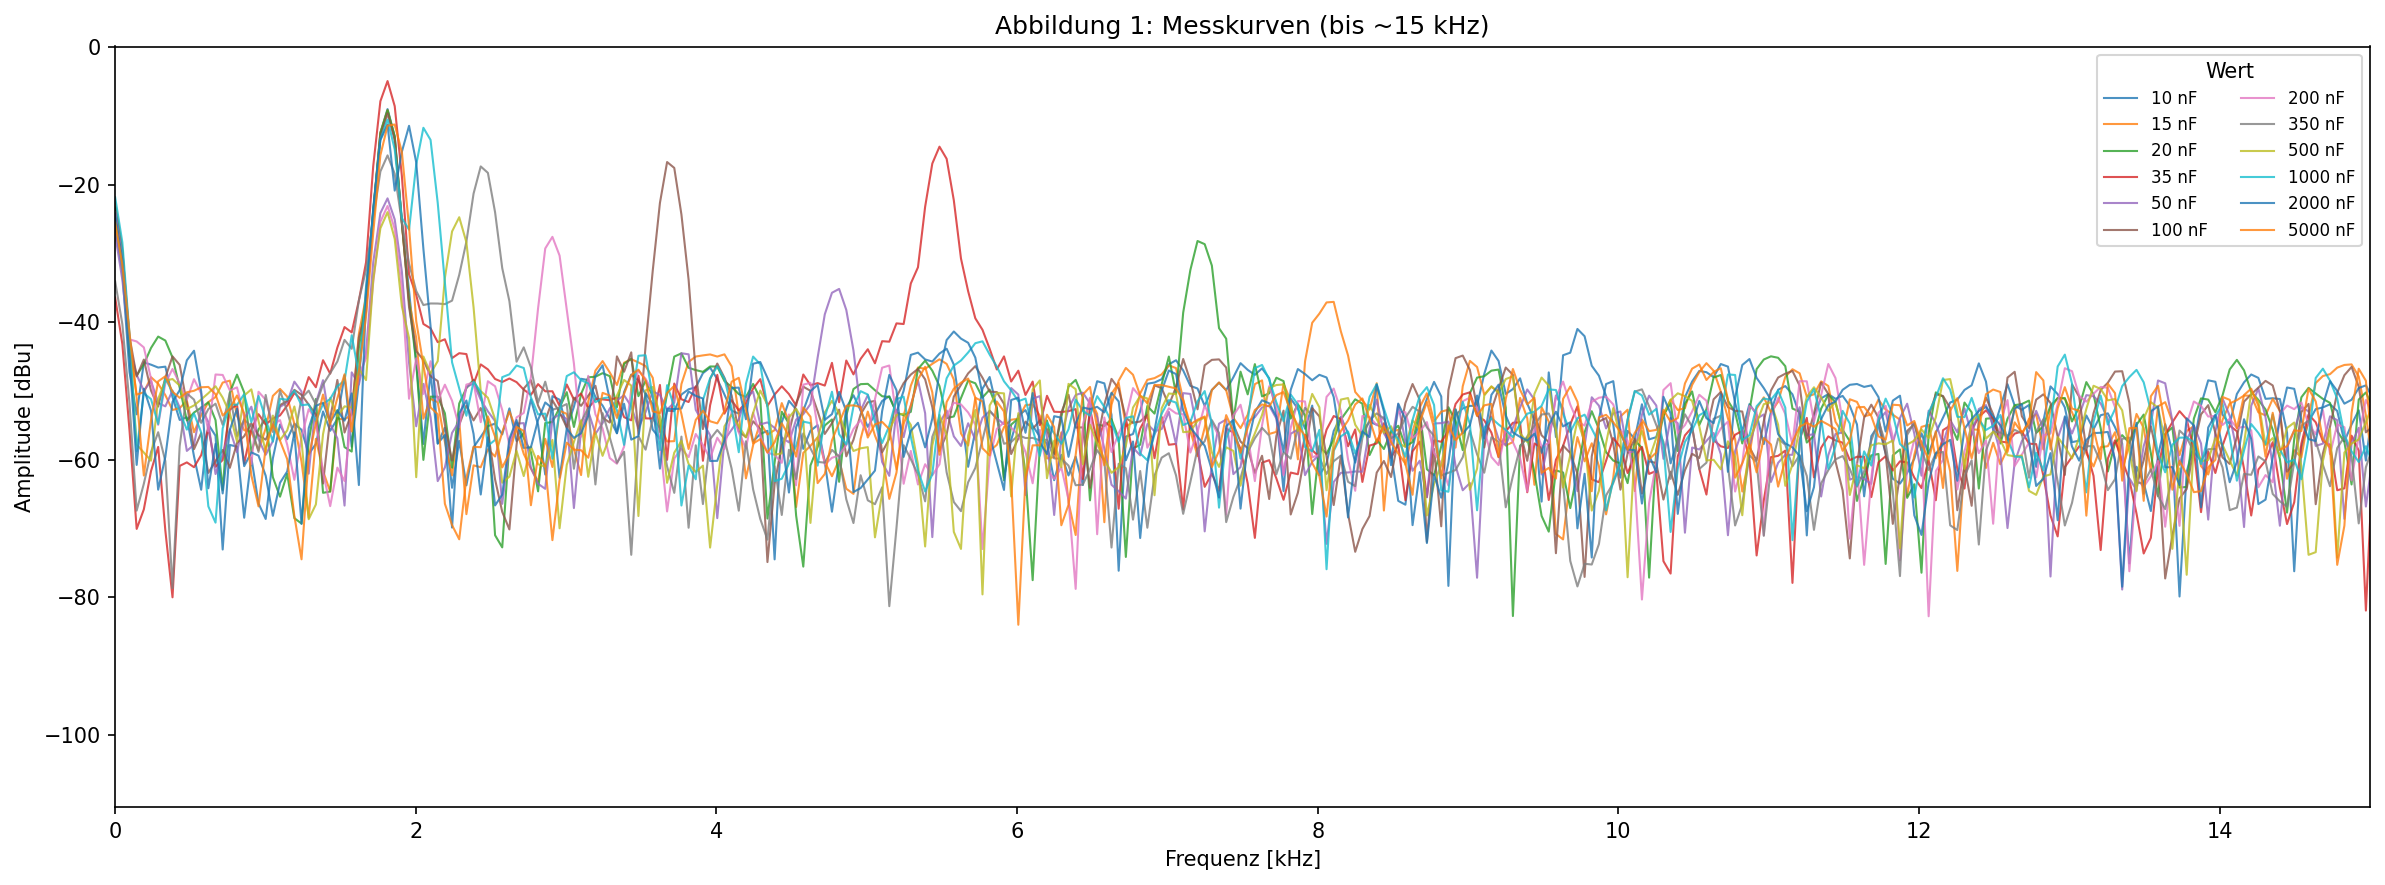

In [9]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional (für besseren Fit). Falls nicht installiert, wird auf numpy ausgewichen.
try:
    from scipy.optimize import curve_fit
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False


# =========================================================
# 1) KONFIGURATION
# =========================================================

# Ordner mit CSV-Dateien (Standard: aktuelles Verzeichnis)
DATA_DIR = Path("./Messdaten/Aufgabe1")  # z.B. Path("./aufgabe1_csv")

# Parameterwerte, die in Dateinamen vorkommen (z.B. "..._10.csv", "..._5000.csv")
ALLOWED_VALUES = [10, 15, 20, 35, 50, 100, 200, 350, 500, 1000, 2000, 5000]

# CSV-Einstellungen
CSV_SEPARATOR_CANDIDATES = [",", ";", "\t"]  # versucht mehrere Trennzeichen
DECIMAL_CANDIDATES = [".", ","]              # versucht Punkt/Komma
ENCODING = "utf-8"                           # bei Problemen: "latin-1"

# Falls du konkrete Spaltennamen hast, setze sie hier (sonst None -> Auto-Erkennung)
X_COLUMN_NAME = None   # z.B. "f_Hz" oder "t_s"
Y_COLUMN_NAME = None   # z.B. "Uout_V" oder "Amplitude"

# Kopplungsgrad-Berechnung:
# - Wenn deine CSV schon eine Spalte "k" hat: setze Y_COLUMN_NAME auf diese Spalte
# - Wenn du ihn berechnen willst (z.B. U2/U1): passe die Funktion unten an.
def compute_coupling_degree(df: pd.DataFrame, x_col: str, y_col: str) -> float:
    """
    Liefert einen einzelnen Kopplungsgrad-Wert pro Datei.
    Standard: Mittelwert der Y-Spalte (robust, wenn Y bereits 'Kopplungsgrad' o.ä. ist).
    """
    y = pd.to_numeric(df[y_col], errors="coerce").dropna()
    return float(y.mean())


# Fit-Modell für Kopplungsgrad vs. Parameterwert
# Oft funktionieren "Sättigung" oder "abklingend" gut:
def model_saturating(x, a, b, c):
    # c + a*(1 - exp(-b*x))  (monoton steigend, sättigt)
    return c + a * (1.0 - np.exp(-b * x))

def model_decay(x, a, b, c):
    # c + a*exp(-b*x)  (monoton fallend, nähert sich c)
    return c + a * np.exp(-b * x)

FIT_MODEL = "decay"  # "decay" oder "saturating"


# =========================================================
# 2) HILFSFUNKTIONEN
# =========================================================

def extract_value_from_filename(filename: str) -> int | None:
    """
    Sucht eine der erlaubten Zahlen als 'Ganzwort' im Dateinamen.
    Beispiel: messung_200.csv -> 200
    """
    for v in sorted(ALLOWED_VALUES, reverse=True):
        if re.search(rf"(^|[^0-9]){v}([^0-9]|$)", filename):
            return v
    return None

def read_csv_robust(path: Path) -> pd.DataFrame:
    """
    Probiert typische CSV-Varianten (Trennzeichen, Dezimal).
    """
    last_err = None
    for sep in CSV_SEPARATOR_CANDIDATES:
        for dec in DECIMAL_CANDIDATES:
            try:
                df = pd.read_csv(path, sep=sep, decimal=dec, encoding=ENCODING)
                # mindestens 2 Spalten sinnvoll
                if df.shape[1] >= 2:
                    return df
            except Exception as e:
                last_err = e
    raise RuntimeError(f"Konnte CSV nicht robust lesen: {path.name}. Letzter Fehler: {last_err}")

def pick_xy_columns(df: pd.DataFrame) -> tuple[str, str]:
    """
    Wählt X/Y-Spalten:
    - Wenn X_COLUMN_NAME / Y_COLUMN_NAME gesetzt sind, nimmt die
    - sonst: erste zwei numerisch interpretierbaren Spalten
    """
    if X_COLUMN_NAME is not None and Y_COLUMN_NAME is not None:
        if X_COLUMN_NAME not in df.columns or Y_COLUMN_NAME not in df.columns:
            raise ValueError(
                f"Spaltennamen nicht gefunden. Vorhanden: {list(df.columns)}"
            )
        return X_COLUMN_NAME, Y_COLUMN_NAME

    # Auto: suche numerische Spalten
    numeric_cols = []
    for col in df.columns:
        series = pd.to_numeric(df[col], errors="coerce")
        if series.notna().sum() > max(5, int(0.5 * len(series))):  # mindestens halbwegs numerisch
            numeric_cols.append(col)

    if len(numeric_cols) < 2:
        raise ValueError(f"Zu wenige numerische Spalten gefunden. Spalten: {list(df.columns)}")

    return numeric_cols[0], numeric_cols[1]

def fit_coupling(x_vals: np.ndarray, k_vals: np.ndarray):
    """
    Fit für Kopplungsgrad vs Parameter.
    Nutzt scipy, falls verfügbar. Sonst einfacher Fallback.
    """
    if FIT_MODEL == "saturating":
        f = model_saturating
        # Startwerte grob
        p0 = [max(k_vals) - min(k_vals), 0.001, min(k_vals)]
    else:
        f = model_decay
        p0 = [max(k_vals) - min(k_vals), 0.001, min(k_vals)]

    if SCIPY_OK and len(x_vals) >= 3:
        popt, pcov = curve_fit(f, x_vals, k_vals, p0=p0, maxfev=20000)
        return f, popt
    else:
        # Fallback: keine echte Optimierung, nur "nimm Startwerte"
        return f, np.array(p0, dtype=float)


# =========================================================
# 3) HAUPTPROGRAMM
# =========================================================

def main():
    csv_files = sorted(DATA_DIR.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Keine CSV-Dateien in {DATA_DIR.resolve()} gefunden.")

    curves = []          # (value, x, y, filename)
    coupling_points = [] # (value, k, filename)

    for path in csv_files:
        v = extract_value_from_filename(path.stem)
        if v is None:
            # Datei ignorieren, wenn kein Parameterwert im Namen steckt
            continue

        df = read_csv_robust(path)
        x_col, y_col = pick_xy_columns(df)

        x = pd.to_numeric(df[x_col], errors="coerce").to_numpy()
        y = pd.to_numeric(df[y_col], errors="coerce").to_numpy()

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        if len(x) < 2:
            continue

        curves.append((v, x, y, path.name))

        k = compute_coupling_degree(df, x_col, y_col)
        coupling_points.append((v, k, path.name))

    if not curves:
        raise RuntimeError(
            "Es wurden keine Dateien verarbeitet. "
            "Achte darauf, dass die Dateinamen einen der Werte enthalten (10, 15, ..., 5000)."
        )

    # Sortieren nach Parameterwert
    curves.sort(key=lambda t: t[0])
    coupling_points.sort(key=lambda t: t[0])

    # -----------------------------
    # Abbildung 1: Messkurven (bis ~15 kHz) + "gestreckt"
    # -----------------------------
    plt.figure(figsize=(16, 6), dpi=150)  # <- streckt/bessere Auflösung

    for v, x, y, fname in curves:
        plt.plot(x, y, label=f"{str(v)} nF", linewidth=1, alpha=0.8)

    # Wenn x in Hz vorliegt: 15 kHz = 15000
    # Wenn x in kHz vorliegt (z.B. 0..200): 15 kHz = 15
    x_max = max(np.nanmax(x) for _, x, _, _ in curves)

    if x_max > 1000:     # sehr wahrscheinlich Hz
        plt.xlim(0, 15000)
        plt.xlabel("Frequenz / Hz")
    else:                # sehr wahrscheinlich kHz
        plt.xlim(0, 15)
        plt.xlabel("Frequenz [kHz]")

    plt.ylabel("Amplitude [dBu]")
    plt.title("Abbildung 1: Messkurven (bis ~15 kHz)")
    plt.legend(title="Wert", ncols=2, fontsize=8)
    plt.tight_layout()

    # # -----------------------------
    # # Abbildung 2: Kopplungsgrad + Fit
    # # -----------------------------
    # x_vals = np.array([t[0] for t in coupling_points], dtype=float)
    # k_vals = np.array([t[1] for t in coupling_points], dtype=float)

    # f, popt = fit_coupling(x_vals, k_vals)

    # x_fit = np.linspace(x_vals.min(), x_vals.max(), 300)
    # k_fit = f(x_fit, *popt)

    # plt.figure()
    # plt.scatter(x_vals, k_vals, label="Kopplungsgrad (pro Datei)")
    # plt.plot(x_fit, k_fit, label=f"Fit ({FIT_MODEL})")
    # plt.xlabel("Parameterwert")
    # plt.ylabel("Kopplungsgrad k")
    # plt.title("Darstellung und Fit der Kopplungsgrade")
    # plt.legend()
    # plt.tight_layout()

    # plt.show()


if __name__ == "__main__":
    main()
